In [ ]:
import os
import requests
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# CONFIGURAÇÕES
# ==========================================

# 1. Link da imagem que você quer usar como entrada/guia para a difusão
INPUT_IMAGE_URL = "https://cdn.myanimelist.net/images/anime/1015/138006.jpg" 

# Tamanho solicitado de 10x10 pixels
IMAGE_SIZE = (10, 10) 

# Definindo cabeçalho para evitar bloqueio (Erro 403) ao baixar as imagens dos servidores
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

# ==========================================
# FUNÇÃO AUXILIAR DE DOWNLOAD E DOWNSCALE
# ==========================================

def baixar_e_processar_imagem(url, target_size):
    try:
        response = requests.get(url, headers=HEADERS, timeout=5)
        response.raise_for_status()
        img_arr = np.array(bytearray(response.content), dtype=np.uint8)
        img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Reduz para 10x10 pixels
        img_10x10 = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        # Normaliza os tons dos pixels entre 0.0 e 1.0
        return img_10x10.astype(np.float32) / 255.0
    except Exception as e:
        return None

# ==========================================
# EXECUÇÃO DO FLUXO COMPLETO
# ==========================================

if __name__ == "__main__":
    print("--- PASSO 1: Carregando banco de dados de Animes ---")
    if not os.path.exists("banco_de_dados_animes_limpo.csv"):
        raise FileNotFoundError("Por favor, certifique-se de que o arquivo 'banco_de_dados_animes_limpo.csv' está na mesma pasta.")
        
    df = pd.read_csv("banco_de_dados_animes_limpo.csv")
    urls_treino = df['Image_URL'].dropna().tolist()
    
    print("Baixando e redimensionando imagens para criar o conjunto de dados base...")
    imagens_treino = []
    for url in urls_treino:
        img = baixar_e_processar_imagem(url, IMAGE_SIZE)
        if img is not None:
            imagens_treino.append(img.flatten()) # Transforma a matriz 10x10x3 em um vetor de 300 posições
        # Limitando a 4 imagens para o treinamento da Floresta não demorar demais na sua CPU
        if len(imagens_treino) >= 4: 
            break
            
    if len(imagens_treino) == 0:
        print("Falha ao baixar imagens do CSV. Gerando dados de treino sintéticos para não travar o script...")
        imagens_treino = [np.random.rand(300) for _ in range(3)]
        
    X_dados = np.array(imagens_treino)
    print(f"Dataset de treino criado com sucesso. Formato da matriz de dados: {X_dados.shape}")

    print("\n--- PASSO 2: Treinando o Modelo (Denoising Score Matching) ---")
    # Hiperparâmetros de ruído extraídos exatamente do seu difusao.ipynb
    sigmas = np.array([1.0, 0.5, 0.2, 0.1, 0.05])
    n_perturbacoes = 80  # Quantidade de variações de ruído criadas para cada imagem/sigma
    
    X_train = []
    y_train = []
    rng = np.random.default_rng(42)
    
    #mudar para rede neural convolucional
    # Criando o dataset poluído por ruído para ensinar o "score" à floresta
    for x_0 in X_dados:
        for s in sigmas:  #aumentar a quantidade de sigmas
            for _ in range(n_perturbacoes):
                z = rng.standard_normal(x_0.shape)
                x_ruidoso = x_0 + s * z
                
                # O "score" alvo que o modelo precisa prever é: -z / sigma
                score_alvo = -z / s
                
                # A entrada do modelo contém os 300 pixels + 1 coluna indicando o nível do sigma atual
                feature = np.concatenate([x_ruidoso, [s]])
                
                X_train.append(feature)
                y_train.append(score_alvo)
                
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    
    print("Treinando a RandomForestRegressor... (Aguarde alguns segundos)")
    # n_jobs=-1 usa todos os núcleos do seu processador para acelerar o cálculo
    modelo_floresta = RandomForestRegressor(n_estimators=60, max_depth=12, random_state=42, n_jobs=-1)
    modelo_floresta.fit(X_train, y_train)
    print("Modelo treinado e pronto!")




--- PASSO 1: Carregando banco de dados de Animes ---
Baixando e redimensionando imagens para criar o conjunto de dados base...
Dataset de treino criado com sucesso. Formato da matriz de dados: (4, 300)

--- PASSO 2: Treinando o Modelo (Denoising Score Matching) ---
Treinando a RandomForestRegressor... (Aguarde alguns segundos)
Modelo treinado e pronto!



--- PASSO 3: Baixando Imagem de Entrada do Usuário ---

--- PASSO 4: Executando Algoritmo de Difusão (Langevin Anelado) ---

--- PASSO 5: Exibindo e Salvando os Resultados ---
Concluído! A imagem comparativa foi salva como 'resultado_gerado.png'.


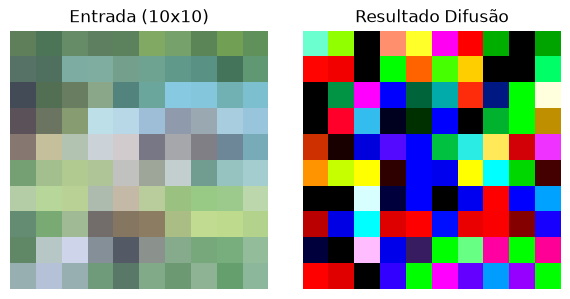

In [4]:

print("\n--- PASSO 3: Baixando Imagem de Entrada do Usuário ---")
img_alvo = baixar_e_processar_imagem(INPUT_IMAGE_URL, IMAGE_SIZE)
if img_alvo is None:
    print("Não foi possível acessar a URL informada. Usando imagem padrão aleatória.")
    img_alvo = rng.uniform(0, 1, (10, 10, 3))
        
vetor_alvo = img_alvo.flatten()

print("\n--- PASSO 4: Executando Algoritmo de Difusão (Langevin Anelado) ---")
T = 20
c = 0.02
    
# Começa o processo gerando um ruído Gaussiano puro baseado no maior sigma
x_processo = rng.standard_normal(vetor_alvo.shape) * sigmas[0]
    
# Loop de amostragem reversa (Algoritmo do notebook)
for s in sigmas:
    alpha = c * (s ** 2)
    for _ in range(T):
        z = rng.standard_normal(x_processo.shape)
            
        # Monta a estrutura da linha para o predict: [pixels_atuais, sigma]
        entrada_modelo = np.concatenate([x_processo, [s]]).reshape(1, -1)
        score_predito = modelo_floresta.predict(entrada_modelo)[0]
            
        # Atualização de Langevin (Equação diferencial estocástica do notebook)
        x_processo = x_processo + 0.5 * alpha * score_predito + np.sqrt(alpha) * z
            
# Reconverte o vetor de 300 elementos de volta para uma matriz de imagem 10x10x3 (RGB)
img_final = np.clip(x_processo.reshape(10, 10, 3), 0, 1)

print("\n--- PASSO 5: Exibindo e Salvando os Resultados ---")
plt.figure(figsize=(6, 3))
    
# Mostra como ficou a imagem original reduzida a 10x10
plt.subplot(1, 2, 1)
plt.title("Entrada (10x10)")
plt.imshow(img_alvo)
plt.axis('off')
    
    # Mostra o resultado após passar pelo campo de difusão aprendido
plt.subplot(1, 2, 2)
plt.title("Resultado Difusão")
plt.imshow(img_final)
plt.axis('off')
    
plt.tight_layout()
plt.savefig("resultado_gerado.png")
print("Concluído! A imagem comparativa foi salva como 'resultado_gerado.png'.")
plt.show()